# 00 — Data Overview (Raw GEE Data)

This notebook explores the original satellite-derived water quality data
obtained directly from Google Earth Engine.
The purpose is to understand data structure, temporal coverage, and missing values
before preprocessing.


Cell 2 — Import Library

In [1]:
import pandas as pd
import matplotlib.pyplot as plt


Cell 3 — Load Raw Data

In [2]:
path = "../data/raw/CP01_Chumphon_River_2017_2025.csv"
df = pd.read_csv(path)

df.head()


,system:index,Chlorophyll_a,DO,Date,Salinity,Secchi_Depth,TSI,Turbidity,pH,.geo
0,20180211T033851_20180211T035058_T47PNM,13.044897,9.577152,2018-02-11,0.033180,1.490897,55.710300,104.961008,7.354302,"{""type"":""MultiPoint"",""coordinates"":[]}"
1,20181223T034149_20181223T035212_T47PNM,15.545221,9.576649,2018-12-23,0.185210,2.155660,57.470359,101.192413,7.151211,"{""type"":""MultiPoint"",""coordinates"":[]}"
2,20190107T034131_20190107T034202_T47PNM,9.583124,9.576868,2019-01-07,0.113281,1.171259,52.549408,147.184875,6.903548,"{""type"":""MultiPoint"",""coordinates"":[]}"
3,20190122T034049_20190122T034312_T47PNM,11.686933,9.577185,2019-01-22,0.103878,2.269558,54.445535,119.882385,6.665801,"{""type"":""MultiPoint"",""coordinates"":[]}"
4,20190127T034021_20190127T035506_T47PNM,6.329872,9.577378,2019-01-27,0.031797,1.280936,47.911765,168.948782,-5.750657,"{""type"":""MultiPoint"",""coordinates"":[]}"


Cell 4 — Basic Structure Check

In [3]:
df.info()
df.describe(include="all")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126 entries, 0 to 125
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   system:index   126 non-null    object 
 1   Chlorophyll_a  126 non-null    float64
 2   DO             126 non-null    float64
 3   Date           126 non-null    object 
 4   Salinity       126 non-null    float64
 5   Secchi_Depth   126 non-null    float64
 6   TSI            126 non-null    float64
 7   Turbidity      126 non-null    float64
 8   pH             126 non-null    float64
 9   .geo           126 non-null    object 
dtypes: float64(7), object(3)
memory usage: 10.0+ KB


,system:index,Chlorophyll_a,DO,Date,Salinity,Secchi_Depth,TSI,Turbidity,pH,.geo
count,126,126.000000,126.000000,126,126.000000,126.000000,126.000000,126.000000,126.000000,126
unique,126,NaN,NaN,126,NaN,NaN,NaN,NaN,NaN,1
top,20180211T033851_20180211T035058_T47PNM,NaN,NaN,2018-02-11,NaN,NaN,NaN,NaN,NaN,"{""type"":""MultiPoint"",""coordinates"":[]}"
freq,1,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,126
mean,NaN,13.448206,9.577245,NaN,0.058183,1.621843,55.643275,116.535495,6.566150,NaN
std,NaN,2.789600,0.000368,NaN,0.040612,0.303530,2.182725,14.701625,3.094643,NaN
min,NaN,6.329872,9.575979,NaN,0.004411,1.106308,47.911765,96.992954,-24.653717,NaN
25%,NaN,11.772111,9.577051,NaN,0.024991,1.455151,54.652482,105.534346,6.632914,NaN
50%,NaN,13.260714,9.577210,NaN,0.038880,1.546681,55.792418,110.595080,7.247089,NaN
75%,NaN,14.829168,9.577377,NaN,0.089881,1.674557,56.934876,125.845044,7.332478,NaN


Cell 5 — Check Time Coverage

In [9]:
df["date"] = pd.to_datetime(df["Date"])
print(df["date"].min(), "→", df["date"].max())


2018-02-11 00:00:00 → 2025-12-16 00:00:00


Cell 6 — Detect Invalid Values

In [10]:
invalid_mask = (df == -9999).sum()
invalid_mask


system:index     0
Chlorophyll_a    0
DO               0
Date             0
Salinity         0
Secchi_Depth     0
TSI              0
Turbidity        0
pH               0
.geo             0
date             0
dtype: int64

Cell 7 — Visualize Raw Time Series (1 ตัวอย่าง)

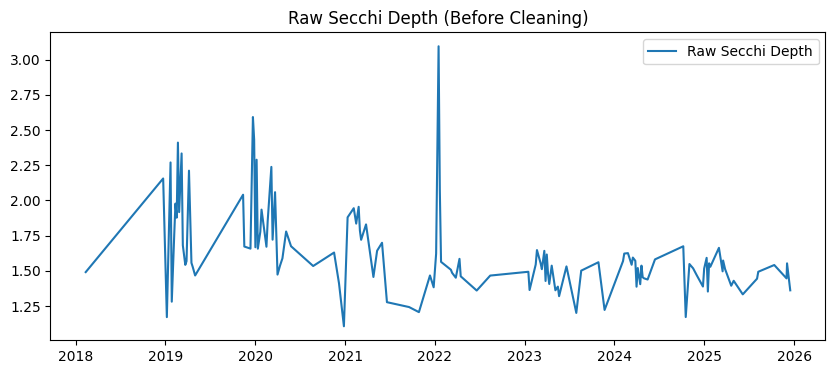

In [12]:
plt.figure(figsize=(10,4))
plt.plot(df["date"], df["Secchi_Depth"], label="Raw Secchi Depth")
plt.title("Raw Secchi Depth (Before Cleaning)")
plt.legend()
plt.show()


## Summary

- The dataset is directly obtained from Google Earth Engine.
- Missing and invalid values (e.g., -9999) are present due to satellite limitations.
- Temporal gaps exist and require preprocessing before modeling.
- This notebook does not modify data and serves as a reference for data authenticity.
